# **Install all required packages.**

In [1]:
!pip install torch torchvision --quiet
!pip install Pillow matplotlib numpy requests tqdm --quiet
!pip install gradio --quiet
!pip install scikit-image --quiet

print("✅ All packages installed successfully.")

✅ All packages installed successfully.


# **IMPORTS & DEVICE SETUP**

In [2]:
import os
import copy
import time
import math
import requests
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import save_image
from skimage import color as skcolor

warnings.filterwarnings("ignore")
matplotlib.rcParams['figure.dpi'] = 120

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Running on: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Training will be slow. Enable GPU in Colab settings.")

# Global image size
# 512 for GPU, 256 for CPU (to keep it reasonable)
IMG_SIZE = 512 if device.type == 'cuda' else 256
print(f"   Image size set to: {IMG_SIZE}×{IMG_SIZE}")

🖥️  Running on: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
   Image size set to: 512×512


# **DATASET & VISUALIZATION**

📥 Downloading dataset images...
   Content [golden_gate]: ✅
   ⚠️  Could not download https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg: 429 Client Error: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg
   Content [paris_street]: ❌
   ⚠️  Could not download https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/402px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg: 429 Client Error: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retou

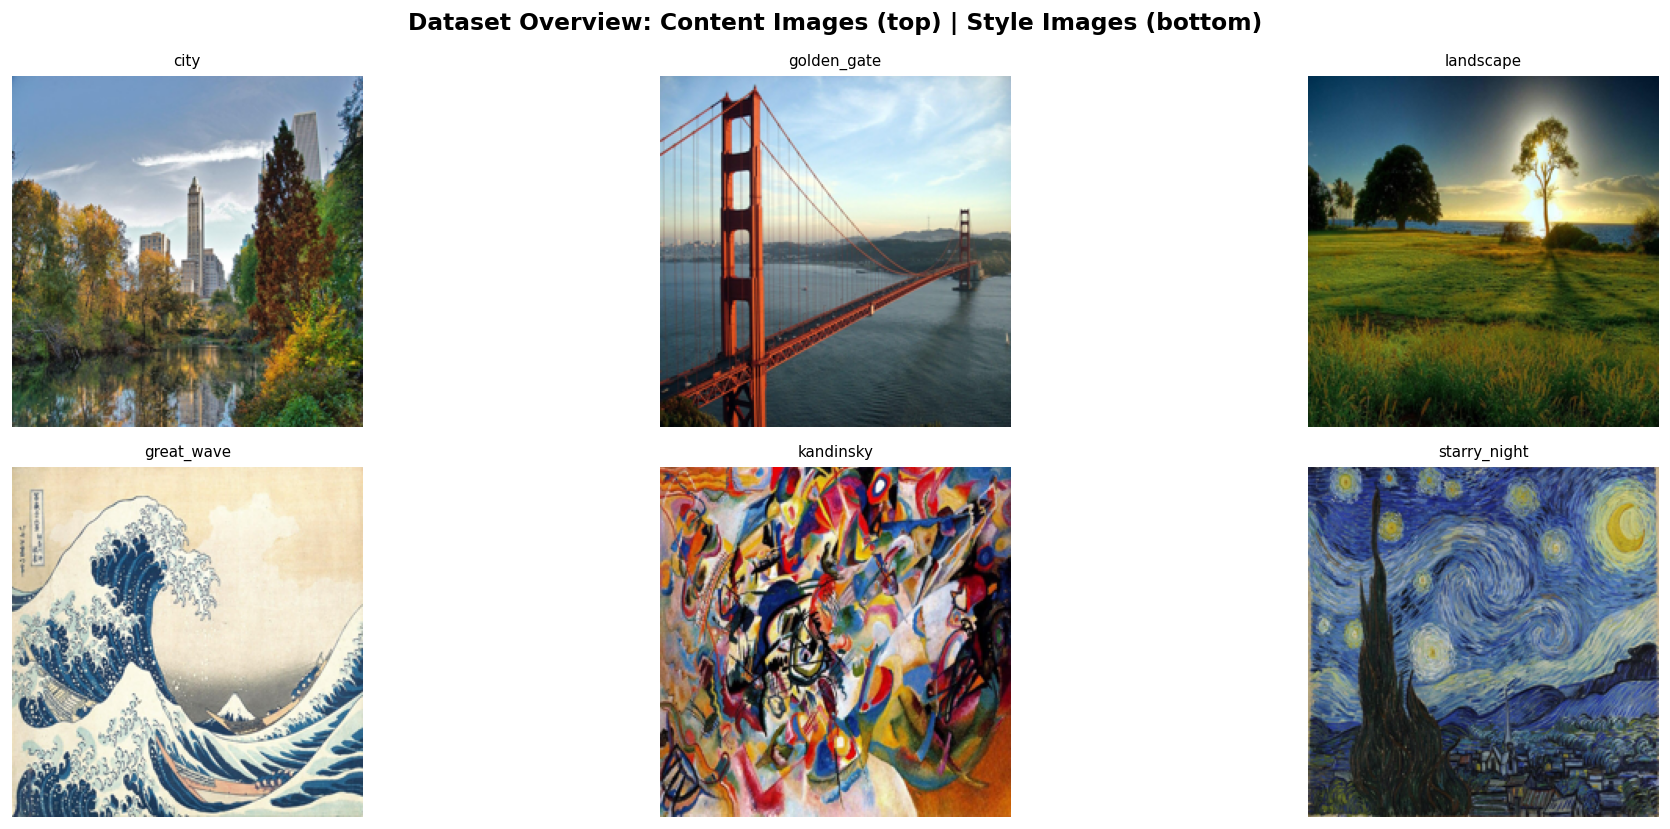

📊 Dataset grid saved to images/output/dataset_overview.png


In [3]:
os.makedirs("images/content", exist_ok=True)
os.makedirs("images/style",   exist_ok=True)
os.makedirs("images/output",  exist_ok=True)

# Image sources
# Content images from COCO (publicly accessible direct URLs)
CONTENT_IMAGES = {
    "golden_gate":  "https://upload.wikimedia.org/wikipedia/commons/thumb/0/0c/GoldenGateBridge-001.jpg/1280px-GoldenGateBridge-001.jpg",
    "paris_street":  "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg",
    "portrait":     "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/402px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg",
    "landscape":    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1a/24701-nature-natural-beauty.jpg/1280px-24701-nature-natural-beauty.jpg",
    "city":         "https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/Southwest_corner_of_Central_Park%2C_looking_east%2C_NYC.jpg/1280px-Southwest_corner_of_Central_Park%2C_looking_east%2C_NYC.jpg",
}

# Style images: famous paintings (all public domain via Wikimedia)
STYLE_IMAGES = {
    "starry_night":     "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg",
    "great_wave":       "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Tsunami_by_hokusai_19th_century.jpg/1280px-Tsunami_by_hokusai_19th_century.jpg",
    "kandinsky":        "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg/1280px-Vassily_Kandinsky%2C_1913_-_Composition_7.jpg",
    "mosaic":           "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Tsunami_by_hokusai_19th_century.jpg/640px-Tsunami_by_hokusai_19th_century.jpg",
    "scream":           "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg/800px-Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg",
}

def download_image(url: str, save_path: str, timeout: int = 15) -> bool:
    """Download an image from URL to disk. Returns True on success."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (NST Course Project)'}
        resp = requests.get(url, headers=headers, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(save_path)
        return True
    except Exception as e:
        print(f"   ⚠️  Could not download {url}: {e}")
        return False

print("📥 Downloading dataset images...")
for name, url in CONTENT_IMAGES.items():
    path = f"images/content/{name}.jpg"
    if not os.path.exists(path):
        ok = download_image(url, path)
        print(f"   Content [{name}]: {'✅' if ok else '❌'}")

for name, url in STYLE_IMAGES.items():
    path = f"images/style/{name}.jpg"
    if not os.path.exists(path):
        ok = download_image(url, path)
        print(f"   Style  [{name}]: {'✅' if ok else '❌'}")

print("\n✅ Dataset ready.")

# Visualize dataset samples
def show_dataset_grid(content_dir="images/content", style_dir="images/style"):
    """Display a grid of all downloaded content and style images."""
    content_files = sorted(Path(content_dir).glob("*.jpg"))
    style_files   = sorted(Path(style_dir).glob("*.jpg"))

    fig, axes = plt.subplots(2, max(len(content_files), len(style_files)),
                              figsize=(18, 7))
    fig.suptitle("Dataset Overview: Content Images (top) | Style Images (bottom)",
                  fontsize=14, fontweight='bold')

    for i, cf in enumerate(content_files):
        img = Image.open(cf).resize((224, 224))
        axes[0, i].imshow(img)
        axes[0, i].set_title(cf.stem, fontsize=9)
        axes[0, i].axis('off')
    for j in range(i+1, axes.shape[1]):
        axes[0, j].axis('off')

    for i, sf in enumerate(style_files):
        img = Image.open(sf).resize((224, 224))
        axes[1, i].imshow(img)
        axes[1, i].set_title(sf.stem, fontsize=9)
        axes[1, i].axis('off')
    for j in range(i+1, axes.shape[1]):
        axes[1, j].axis('off')

    plt.tight_layout()
    plt.savefig("images/output/dataset_overview.png", bbox_inches='tight')
    plt.show()
    print("📊 Dataset grid saved to images/output/dataset_overview.png")

show_dataset_grid()

# **IMAGE UTILITIES**

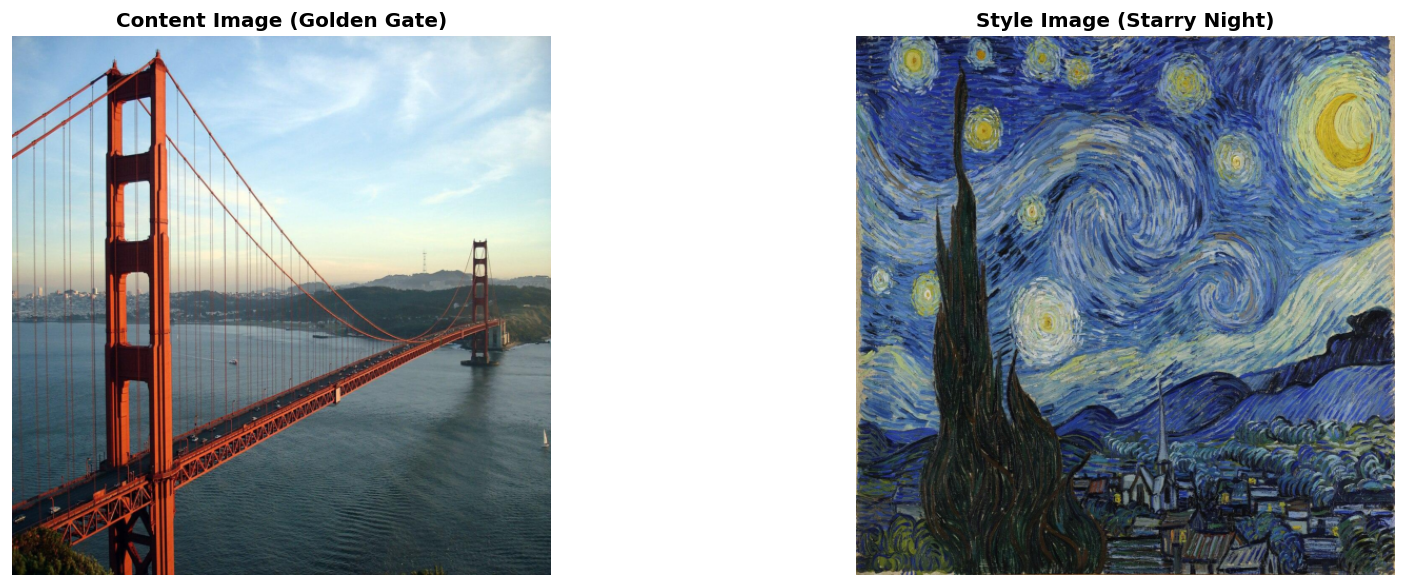

Content tensor shape: torch.Size([1, 3, 512, 512])
Style tensor shape:   torch.Size([1, 3, 512, 512])


In [4]:
# ImageNet normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms: PIL → Tensor (normalized for VGG)
_to_tensor = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# De-normalize: Tensor → PIL (for display)
_denorm_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_denorm_std  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)

def load_image(path_or_pil, size=None) -> torch.Tensor:
    """
    Load an image from file path or PIL Image.
    Returns a (1, 3, H, W) tensor on `device`, normalized for VGG.
    """
    if isinstance(path_or_pil, str):
        img = Image.open(path_or_pil).convert("RGB")
    else:
        img = path_or_pil.convert("RGB")

    if size is not None:
        t = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        t = _to_tensor

    return t(img).unsqueeze(0).to(device)  # shape: (1, C, H, W)


def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    """Convert a VGG-normalized (1,3,H,W) tensor back to PIL Image."""
    img = tensor.cpu().clone().squeeze(0)           # (3, H, W)
    img = img * _denorm_std + _denorm_mean          # de-normalize
    img = img.clamp(0, 1)
    return transforms.ToPILImage()(img)


def show_images(images: list, titles: list, figsize=(16, 5), save_path=None):
    """Side-by-side image display helper."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if isinstance(img, torch.Tensor):
            img = tensor_to_pil(img)
        ax.imshow(img)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def imshow_tensor(tensor: torch.Tensor, title: str = ""):
    """Quick display of a single tensor image."""
    pil = tensor_to_pil(tensor)
    plt.figure(figsize=(6, 6))
    plt.imshow(pil)
    plt.title(title, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Test: load and display one pair
content_path = "images/content/golden_gate.jpg"
style_path   = "images/style/starry_night.jpg"

# Fallback: create synthetic images if downloads failed
if not os.path.exists(content_path):
    synthetic = Image.fromarray(np.random.randint(100, 200, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))
    synthetic.save(content_path)
if not os.path.exists(style_path):
    synthetic = Image.fromarray(np.random.randint(50, 150, (IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))
    synthetic.save(style_path)

content_img = load_image(content_path)
style_img   = load_image(style_path)

show_images(
    [content_img, style_img],
    ["Content Image (Golden Gate)", "Style Image (Starry Night)"],
    save_path="images/output/input_pair.png"
)
print(f"Content tensor shape: {content_img.shape}")
print(f"Style tensor shape:   {style_img.shape}")


# **Model Architecture (VGG19)**

In [5]:

class VGG19Features(nn.Module):
    """
    VGG19 up to conv5_1, with avg-pooling instead of max-pooling.

    Layer naming convention (mirrors Gatys et al.):
        'conv1_1', 'relu1_1', 'conv1_2', 'relu1_2', 'pool1',
        'conv2_1', 'relu2_1', ...  up to 'conv5_1', 'relu5_1'

    Content layers : ['relu4_2']          — captures high-level structure
    Style layers   : ['relu1_1', 'relu2_1', 'relu3_1', 'relu4_1', 'relu5_1']
                     — captures textures at multiple scales
    """

    # Maps torchvision internal index → human-readable layer name
    LAYER_MAP = {
        '0': 'conv1_1',  '1': 'relu1_1',
        '2': 'conv1_2',  '3': 'relu1_2',
        '4': 'pool1',
        '5': 'conv2_1',  '6': 'relu2_1',
        '7': 'conv2_2',  '8': 'relu2_2',
        '9': 'pool2',
        '10': 'conv3_1', '11': 'relu3_1',
        '12': 'conv3_2', '13': 'relu3_2',
        '14': 'conv3_3', '15': 'relu3_3',
        '16': 'conv3_4', '17': 'relu3_4',
        '18': 'pool3',
        '19': 'conv4_1', '20': 'relu4_1',
        '21': 'conv4_2', '22': 'relu4_2',   # ← content layer
        '23': 'conv4_3', '24': 'relu4_3',
        '25': 'conv4_4', '26': 'relu4_4',
        '27': 'pool4',
        '28': 'conv5_1', '29': 'relu5_1',
    }

    def __init__(self,
                 content_layers=('relu4_2',),
                 style_layers=('relu1_1', 'relu2_1', 'relu3_1', 'relu4_1', 'relu5_1')):
        super().__init__()

        # Load pretrained VGG19 (downloads ~550 MB on first run)
        print("📦 Loading VGG19 pretrained weights...")
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        print("   ✅ VGG19 loaded.")

        # Extract only the feature layers we need (up to relu5_1, index 29)
        layers = OrderedDict()
        for idx, layer in enumerate(vgg.features[:30]):
            name = self.LAYER_MAP[str(idx)]
            # Replace MaxPool2d → AvgPool2d (smoother gradients)
            if isinstance(layer, nn.MaxPool2d):
                layer = nn.AvgPool2d(kernel_size=2, stride=2)
            layers[name] = layer

        self.net = nn.Sequential(layers)

        # Freeze all parameters — we only optimize the image, not the network
        for param in self.net.parameters():
            param.requires_grad_(False)

        self.content_layers = set(content_layers)
        self.style_layers   = set(style_layers)
        self.all_target_layers = self.content_layers | self.style_layers

        self.to(device)
        self.eval()

    def forward(self, x: torch.Tensor) -> dict:
        """
        Forward pass: returns dict of {layer_name: feature_map}
        for all content and style layers.
        """
        features = {}
        for name, layer in self.net.named_children():
            x = layer(x)
            if name in self.all_target_layers:
                features[name] = x
                if len(features) == len(self.all_target_layers):
                    break   # early exit — no need to go deeper
        return features


# Instantiate the model (shared across all experiments)
vgg = VGG19Features()

# Print parameter count for report
total_params = sum(p.numel() for p in vgg.net.parameters())
print(f"\n   VGG19 feature extractor: {total_params:,} parameters (all frozen)")
print(f"   Content layers : {sorted(vgg.content_layers)}")
print(f"   Style layers   : {sorted(vgg.style_layers)}")

📦 Loading VGG19 pretrained weights...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 77.0MB/s]


   ✅ VGG19 loaded.

   VGG19 feature extractor: 12,944,960 parameters (all frozen)
   Content layers : ['relu4_2']
   Style layers   : ['relu1_1', 'relu2_1', 'relu3_1', 'relu4_1', 'relu5_1']


# **LOSS FUNCTIONS**

In [6]:
# Three loss components:
#   L_content : MSE between content and generated feature maps at relu4_2
#   L_style   : MSE between Gram matrices at 5 style layers
#   L_tv      : Total Variation — penalizes pixel-level noise (smoothness)
#
# Total loss: L = α·L_content + β·L_style + γ·L_tv

# Gram Matrix
def gram_matrix(feature_map: torch.Tensor) -> torch.Tensor:
    B, C, H, W = feature_map.shape
    F = feature_map.view(B, C, H * W)          # flatten spatial dims
    G = torch.bmm(F, F.transpose(1, 2))        # (B, C, C)
    G = G / (2.0 * C * H * W)                  # normalize
    return G


# Content Loss
class ContentLoss(nn.Module):
    def __init__(self, target_feature: torch.Tensor):
        super().__init__()
        # Detach: target features are fixed — don't backprop through them
        self.target = target_feature.detach()

    def forward(self, generated_feature: torch.Tensor) -> torch.Tensor:
        return 0.5 * F.mse_loss(generated_feature, self.target)


# Style Loss
class StyleLoss(nn.Module):
    def __init__(self, target_feature: torch.Tensor):
        super().__init__()
        self.target_gram = gram_matrix(target_feature).detach()

    def forward(self, generated_feature: torch.Tensor) -> torch.Tensor:
        G_gen = gram_matrix(generated_feature)
        return F.mse_loss(G_gen, self.target_gram)


# Total Variation Loss
def total_variation_loss(img: torch.Tensor) -> torch.Tensor:
    diff_h = img[:, :, 1:, :] - img[:, :, :-1, :]
    diff_w = img[:, :, :, 1:] - img[:, :, :, :-1]
    return (diff_h.abs().mean() + diff_w.abs().mean())

# **IMAGE STATISTICS FOR ADAPTIVE WEIGHTING - 1**

In [7]:
# We compute two statistics that will drive our adaptive α/β:
#   • content_complexity : edge density via Sobel operator
#   • style_richness     : mean Gram matrix norm across style layers

def compute_edge_density(tensor: torch.Tensor) -> float:
    # De-normalize and convert to grayscale
    img = tensor.cpu().clone().squeeze(0)
    img = img * torch.tensor(_denorm_std) .view(3,1,1) + \
              torch.tensor(_denorm_mean).view(3,1,1)
    img = img.clamp(0, 1)
    gray = 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]  # (H, W)
    gray = gray.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)

    # Sobel kernels
    sobel_x = torch.tensor([[[-1., 0., 1.],
                              [-2., 0., 2.],
                              [-1., 0., 1.]]]).unsqueeze(0)
    sobel_y = torch.tensor([[[-1., -2., -1.],
                              [ 0.,  0.,  0.],
                              [ 1.,  2.,  1.]]]).unsqueeze(0)

    edge_x = F.conv2d(gray, sobel_x, padding=1)
    edge_y = F.conv2d(gray, sobel_y, padding=1)
    magnitude = torch.sqrt(edge_x**2 + edge_y**2)

    # Normalize to [0, 1] via 95th percentile to be robust to outliers
    p95 = torch.quantile(magnitude, 0.95).item()
    if p95 < 1e-6:
        return 0.0
    density = (magnitude / p95).clamp(0, 1).mean().item()
    return float(density)


def compute_style_richness(style_features: dict) -> float:
    norms = []
    for feat in style_features.values():
        G = gram_matrix(feat)
        norms.append(G.norm().item() / (G.shape[-1] ** 2))

    richness = np.mean(norms)
    # Clamp and normalize to [0,1] with empirical max ~10
    return float(np.clip(richness / 10.0, 0.0, 1.0))


def compute_adaptive_weights(content_tensor, style_tensor,
                              base_content_w=1.0, base_style_w=1e6):

    # Extract style features for richness computation
    with torch.no_grad():
        style_features = vgg(style_tensor)

    edge_density  = compute_edge_density(content_tensor)
    style_richness = compute_style_richness(style_features)

    # Adaptive scaling:
    # High edge density → increase content weight (preserve structure)
    # High style richness → slightly decrease style weight (avoid chaos)
    content_scale = 1.0 + edge_density          # range: [1.0, 2.0]
    style_scale   = 1.0 - 0.4 * style_richness  # range: [0.6, 1.0]

    alpha = base_content_w * content_scale
    beta  = base_style_w   * style_scale

    diagnostics = {
        'edge_density':    round(edge_density, 4),
        'style_richness':  round(style_richness, 4),
        'content_scale':   round(content_scale, 4),
        'style_scale':     round(style_scale, 4),
        'alpha':           round(alpha, 4),
        'beta':            round(beta, 2),
        'alpha_beta_ratio': round(beta / alpha, 2),
    }
    return alpha, beta, diagnostics

# **COLOR PRESERVATION MODULE - 2**

In [8]:


def pil_to_lab(pil_img: Image.Image):
    """Convert PIL RGB image to LAB. Returns (L, AB) as numpy arrays."""
    rgb = np.array(pil_img).astype(np.float32) / 255.0
    lab = skcolor.rgb2lab(rgb)  # L: [0,100], A: [-128,127], B: [-128,127]
    L  = lab[:, :, 0]
    AB = lab[:, :, 1:]
    return L, AB


def lab_to_pil(L: np.ndarray, AB: np.ndarray) -> Image.Image:
    """Reconstruct PIL RGB image from L and AB channels."""
    lab = np.concatenate([L[:, :, np.newaxis], AB], axis=2)
    # Clip to valid LAB range
    lab[:, :, 0] = np.clip(lab[:, :, 0], 0, 100)
    lab[:, :, 1:] = np.clip(lab[:, :, 1:], -128, 127)
    rgb = skcolor.lab2rgb(lab)  # [0,1]
    rgb = (rgb * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(rgb)


def L_to_tensor(L_channel: np.ndarray) -> torch.Tensor:
    """
    Convert single-channel L (grayscale) to a 3-channel tensor
    suitable for VGG19 (repeating L across R, G, B channels).
    Normalizes L from [0,100] to [0,1] first.
    """
    L_norm = L_channel / 100.0   # [0, 1]
    # Stack as 3 channels (VGG expects 3-channel input)
    L3 = np.stack([L_norm, L_norm, L_norm], axis=2)   # (H, W, 3)
    t = transforms.Compose([
        transforms.ToTensor(),   # (3, H, W), [0,1]
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    pil = Image.fromarray((L3 * 255).clip(0,255).astype(np.uint8))
    return t(pil).unsqueeze(0).to(device)


def tensor_to_L(tensor: torch.Tensor) -> np.ndarray:
    """Convert VGG-normalized tensor back to L channel [0, 100]."""
    img = tensor.cpu().clone().squeeze(0)
    img = img * torch.tensor(IMAGENET_STD).view(3,1,1) + \
              torch.tensor(IMAGENET_MEAN).view(3,1,1)
    img = img.clamp(0, 1)
    # Average across 3 channels (they should be nearly identical)
    L_norm = img.mean(0).numpy()   # (H, W), [0,1]
    return L_norm * 100.0          # → [0, 100]


def prepare_color_preserving_inputs(content_pil: Image.Image,
                                     style_pil:   Image.Image):
    """
    Prepare inputs for color-preserving NST.

    Returns:
        content_L_tensor: (1,3,H,W) tensor of content luminance
        style_L_tensor:   (1,3,H,W) tensor of style luminance
        content_AB:       numpy (H,W,2) content chrominance (to restore later)
        content_L:        numpy (H,W) original content L channel
    """
    size = (IMG_SIZE, IMG_SIZE)
    content_pil = content_pil.resize(size, Image.LANCZOS)
    style_pil   = style_pil.resize(size, Image.LANCZOS)

    content_L, content_AB = pil_to_lab(content_pil)
    style_L,   _          = pil_to_lab(style_pil)

    content_L_tensor = L_to_tensor(content_L)
    style_L_tensor   = L_to_tensor(style_L)

    return content_L_tensor, style_L_tensor, content_AB, content_L


def reconstruct_color_preserved(stylized_tensor: torch.Tensor,
                                  content_AB: np.ndarray) -> Image.Image:
    """
    Reconstruct final image by combining:
      - Stylized L channel (texture from style transfer)
      - Original content AB channels (original colors)
    """
    stylized_L = tensor_to_L(stylized_tensor)   # (H, W), [0,100]
    return lab_to_pil(stylized_L, content_AB)

# **CORE NST OPTIMIZATION LOOP**

In [9]:
# This is the heart of the project: the iterative image optimization.
# The "image" is the optimization variable — network weights are frozen.
#
# Algorithm (Gatys et al.):
#   1. Initialize generated image (from content or random noise)
#   2. Forward pass through frozen VGG19
#   3. Compute L_content + L_style + L_tv
#   4. Backpropagate to IMAGE (not network)
#   5. Update image with L-BFGS optimizer
#   6. Repeat for N iterations

def run_style_transfer(
    content_tensor: torch.Tensor,
    style_tensor:   torch.Tensor,
    content_weight: float  = 1.0,
    style_weight:   float  = 1e6,
    tv_weight:      float  = 1e-4,
    num_steps:      int    = 300,
    init_from:      str    = 'content',  # 'content' or 'noise'
    verbose:        bool   = True,
    log_every:      int    = 50,
    save_intermediates: bool = True,
) -> tuple:

    # ── Target feature extraction ────────────────────────────────────────
    with torch.no_grad():
        content_features = vgg(content_tensor)
        style_features   = vgg(style_tensor)

    # Pre-compute target Gram matrices for all style layers
    style_grams = {layer: gram_matrix(feat).detach()
                   for layer, feat in style_features.items()
                   if layer in vgg.style_layers}

    content_target = {layer: feat.detach()
                      for layer, feat in content_features.items()
                      if layer in vgg.content_layers}

    # ── Initialize generated image ───────────────────────────────────────
    if init_from == 'content':
        generated = content_tensor.clone().requires_grad_(True)
    else:  # white noise
        generated = torch.randn_like(content_tensor).mul(0.001).requires_grad_(True)

    optimizer = optim.LBFGS([generated], max_iter=20, lr=1.0,
                              history_size=100, line_search_fn='strong_wolfe')

    # ── Loss history tracking ────────────────────────────────────────────
    loss_history = {'content': [], 'style': [], 'tv': [], 'total': [], 'step': []}
    intermediates = []
    step_counter = [0]

    # ── Closure: required by L-BFGS ──────────────────────────────────────
    def closure():
        step_counter[0] += 1

        # Clamp image to valid range at each step
        with torch.no_grad():
            generated.clamp_(-2.5, 2.5)  # roughly ±3σ in normalized space

        optimizer.zero_grad()
        gen_features = vgg(generated)

        # Content loss (single layer: relu4_2)
        c_loss = torch.tensor(0.0, device=device)
        for layer, target in content_target.items():
            c_loss = c_loss + 0.5 * F.mse_loss(gen_features[layer], target)

        # Style loss (sum across 5 layers, normalized)
        s_loss = torch.tensor(0.0, device=device)
        n_style = len(vgg.style_layers)
        for layer in vgg.style_layers:
            if layer in gen_features:
                G_gen    = gram_matrix(gen_features[layer])
                G_target = style_grams[layer]
                s_loss   = s_loss + F.mse_loss(G_gen, G_target) / n_style

        # TV loss
        tv_loss = total_variation_loss(generated)

        # Weighted total loss
        total = (content_weight * c_loss +
                 style_weight   * s_loss +
                 tv_weight      * tv_loss)
        total.backward()

        # Logging
        if step_counter[0] % log_every == 0:
            loss_history['step'   ].append(step_counter[0])
            loss_history['content'].append(c_loss.item())
            loss_history['style'  ].append(s_loss.item())
            loss_history['tv'     ].append(tv_loss.item())
            loss_history['total'  ].append(total.item())

            if save_intermediates:
                intermediates.append((step_counter[0], generated.detach().clone()))

            if verbose:
                print(f"   Step {step_counter[0]:4d} | "
                      f"Content: {c_loss.item():.4f} | "
                      f"Style: {s_loss.item():.6f} | "
                      f"TV: {tv_loss.item():.6f} | "
                      f"Total: {total.item():.4f}")

        return total

    # ── Optimization loop ─────────────────────────────────────────────────
    if verbose:
        print(f"\n🎨 Starting style transfer optimization...")
        print(f"   Content weight: {content_weight:.2e} | Style weight: {style_weight:.2e}")
        print(f"   Steps: {num_steps} | Init: {init_from}")
        print("   " + "─" * 65)

    t0 = time.time()
    # L-BFGS calls closure multiple times per step; we track via step_counter
    while step_counter[0] < num_steps:
        optimizer.step(closure)

    elapsed = time.time() - t0
    if verbose:
        print(f"   " + "─" * 65)
        print(f"   ✅ Done in {elapsed:.1f}s  ({step_counter[0]} function evaluations)")

    with torch.no_grad():
        generated.clamp_(-2.5, 2.5)

    return generated.detach(), loss_history, intermediates

In [10]:


def plot_loss_curves(loss_history: dict, title: str = "Loss Curves",
                      save_path: str = None):
    """Plot content, style, TV, and total loss over optimization steps."""
    steps = loss_history['step']
    if not steps:
        print("No loss history to plot.")
        return

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    configs = [
        ('content', 'Content Loss',  '#2196F3'),
        ('style',   'Style Loss',    '#F44336'),
        ('tv',      'TV Loss',       '#4CAF50'),
        ('total',   'Total Loss',    '#FF9800'),
    ]
    for ax, (key, label, color) in zip(axes, configs):
        ax.plot(steps, loss_history[key], color=color, linewidth=2)
        ax.set_xlabel('Optimization Step')
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log' if key in ('style', 'total') else 'linear')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def plot_intermediates(intermediates: list, content: torch.Tensor,
                        style: torch.Tensor, save_path: str = None):
    """Show the evolution of the generated image during optimization."""
    n = len(intermediates)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n + 2, figsize=(4 * (n + 2), 4))
    fig.suptitle("Optimization Progress: Content → Generated → Style",
                  fontsize=13, fontweight='bold')

    axes[0].imshow(tensor_to_pil(content))
    axes[0].set_title("Content", fontsize=10)
    axes[0].axis('off')

    for i, (step, tensor) in enumerate(intermediates):
        axes[i + 1].imshow(tensor_to_pil(tensor))
        axes[i + 1].set_title(f"Step {step}", fontsize=10)
        axes[i + 1].axis('off')

    axes[-1].imshow(tensor_to_pil(style))
    axes[-1].set_title("Style", fontsize=10)
    axes[-1].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def comparison_grid(results: dict, content: torch.Tensor,
                     style: torch.Tensor, save_path: str = None):
    """
    Full comparison grid:
      Row 1: Content | Style
      Row 2: Baseline | Method 1 (Adaptive) | Method 2 (Color-Preserving)
    """
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("Neural Style Transfer: Method Comparison", fontsize=16, fontweight='bold')

    gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.1)

    # Row 1: Input pair (centered)
    ax_c = fig.add_subplot(gs[0, 0])
    ax_s = fig.add_subplot(gs[0, 2])
    ax_c.imshow(tensor_to_pil(content));  ax_c.set_title("Content Image",  fontsize=12, fontweight='bold'); ax_c.axis('off')
    ax_s.imshow(tensor_to_pil(style));    ax_s.set_title("Style Image",    fontsize=12, fontweight='bold'); ax_s.axis('off')

    # Hide middle cell in row 1
    fig.add_subplot(gs[0, 1]).axis('off')

    # Row 2: Three methods
    method_names = ['baseline', 'adaptive', 'color_preserving']
    display_names = [
        "Baseline\n(Gatys et al.)",
        "Ours: Adaptive\nWeighting [N1]",
        "Ours: Color-\nPreserving [N2]"
    ]
    colors = ['#ffffff', '#e3f2fd', '#e8f5e9']

    for col, (key, name, bg) in enumerate(zip(method_names, display_names, colors)):
        ax = fig.add_subplot(gs[1, col])
        if key in results:
            img = results[key]
            if isinstance(img, torch.Tensor):
                img = tensor_to_pil(img)
            ax.imshow(img)
        ax.set_title(name, fontsize=11, fontweight='bold',
                      bbox=dict(boxstyle='round', facecolor=bg, alpha=0.8))
        ax.axis('off')

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"📊 Comparison grid saved to {save_path}")

# **EXPERIMENT 1: BASELINE NST (Gatys et al.)**

In [11]:
#EXPERIMENT 1

print("=" * 70)
print("EXPERIMENT 1: BASELINE NST (Gatys et al., 2015)")
print("  Fixed weights: α=1.0, β=1e6, γ=1e-4")
print("=" * 70)

# Choose images for the main experiment
CONTENT_PATH = "images/content/golden_gate.jpg"
STYLE_PATH   = "images/style/starry_night.jpg"

# Load images
content_img = load_image(CONTENT_PATH)
style_img   = load_image(STYLE_PATH)

# Show inputs
show_images(
    [content_img, style_img],
    ["Content: Golden Gate Bridge", "Style: Starry Night (Van Gogh)"],
    save_path="images/output/experiment_inputs.png"
)

# Run baseline
baseline_output, baseline_losses, baseline_ints = run_style_transfer(
    content_tensor=content_img,
    style_tensor=style_img,
    content_weight=1.0,
    style_weight=1e6,
    tv_weight=1e-4,
    num_steps=300,
    init_from='content',
    verbose=True,
    log_every=50,
    save_intermediates=True,
)

# Save output
baseline_pil = tensor_to_pil(baseline_output)
baseline_pil.save("images/output/baseline_output.png")

# Visualize
show_images(
    [content_img, style_img, baseline_output],
    ["Content", "Style", "Baseline Output"],
    figsize=(18, 6),
    save_path="images/output/baseline_result.png"
)
plot_loss_curves(baseline_losses, "Baseline Loss Curves",
                  save_path="images/output/baseline_losses.png")
plot_intermediates(baseline_ints, content_img, style_img,
                    save_path="images/output/baseline_intermediates.png")

# Quantitative metrics
print(f"\n📊 Baseline Metrics:")
print(f"   Final Content Loss : {baseline_losses['content'][-1]:.6f}")
print(f"   Final Style Loss   : {baseline_losses['style'][-1]:.8f}")
print(f"   Final Total Loss   : {baseline_losses['total'][-1]:.6f}")


Output hidden; open in https://colab.research.google.com to view.

# **EXPERIMENT 2: NOVELTY 1 — ADAPTIVE WEIGHTING**

In [12]:
# EXPERIMENT 2

print("=" * 70)
print("EXPERIMENT 2: NOVELTY 1 — Adaptive Content-Style Weighting")
print("  Weights are automatically computed from image statistics.")
print("=" * 70)

# Compute adaptive weights
alpha, beta, diag = compute_adaptive_weights(
    content_tensor=content_img,
    style_tensor=style_img,
    base_content_w=1.0,
    base_style_w=1e6,
)

print(f"\n📐 Adaptive Weight Diagnostics:")
for k, v in diag.items():
    print(f"   {k:25s}: {v}")
print(f"\n   → α (content weight): {alpha:.4f}")
print(f"   → β (style weight):   {beta:.2f}")

# Run with adaptive weights
adaptive_output, adaptive_losses, adaptive_ints = run_style_transfer(
    content_tensor=content_img,
    style_tensor=style_img,
    content_weight=alpha,
    style_weight=beta,
    tv_weight=1e-4,
    num_steps=300,
    init_from='content',
    verbose=True,
    log_every=50,
    save_intermediates=True,
)

adaptive_pil = tensor_to_pil(adaptive_output)
adaptive_pil.save("images/output/adaptive_output.png")

show_images(
    [content_img, style_img, adaptive_output],
    ["Content", "Style", "Adaptive Weighting Output"],
    figsize=(18, 6),
    save_path="images/output/adaptive_result.png"
)
plot_loss_curves(adaptive_losses, "Adaptive Weighting Loss Curves",
                  save_path="images/output/adaptive_losses.png")

print(f"\n📊 Adaptive Metrics:")
print(f"   Final Content Loss : {adaptive_losses['content'][-1]:.6f}")
print(f"   Final Style Loss   : {adaptive_losses['style'][-1]:.8f}")
print(f"   Final Total Loss   : {adaptive_losses['total'][-1]:.6f}")

Output hidden; open in https://colab.research.google.com to view.

# **EXPERIMENT 3: NOVELTY 2 — COLOR-PRESERVING NST**

In [13]:
# EXPERIMENT 3

print("=" * 70)
print("EXPERIMENT 3: NOVELTY 2 — Color-Preserving Style Transfer (LAB)")
print("  Style transfer on luminance only; colors from content preserved.")
print("=" * 70)

# Load as PIL for LAB conversion
content_pil = Image.open(CONTENT_PATH).convert("RGB")
style_pil   = Image.open(STYLE_PATH).convert("RGB")

# Prepare luminance-only inputs
(content_L_tensor,
 style_L_tensor,
 content_AB,
 content_L) = prepare_color_preserving_inputs(content_pil, style_pil)

print(f"   Content L channel range: [{content_L.min():.1f}, {content_L.max():.1f}]")
print(f"   Style transfer will run only on luminance channel.")

# Visualize LAB decomposition
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("LAB Color Space Decomposition", fontsize=13, fontweight='bold')

cp = content_pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
sp = style_pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
c_L, c_AB = pil_to_lab(cp)
s_L, s_AB = pil_to_lab(sp)

axes[0,0].imshow(cp);                    axes[0,0].set_title("Content RGB");   axes[0,0].axis('off')
axes[0,1].imshow(c_L, cmap='gray');      axes[0,1].set_title("Content L");     axes[0,1].axis('off')

# ✅ FIXED LINE (was causing error)
axes[0,2].imshow(c_AB[..., 0], cmap='coolwarm'); axes[0,2].set_title("Content A"); axes[0,2].axis('off')

axes[1,0].imshow(sp);                    axes[1,0].set_title("Style RGB");     axes[1,0].axis('off')
axes[1,1].imshow(s_L, cmap='gray');      axes[1,1].set_title("Style L");       axes[1,1].axis('off')

# ✅ FIXED LINE (was causing error)
axes[1,2].imshow(s_AB[..., 0], cmap='coolwarm'); axes[1,2].set_title("Style A"); axes[1,2].axis('off')

plt.tight_layout()
plt.savefig("images/output/lab_decomposition.png", bbox_inches='tight', dpi=150)
plt.show()

# ── Run color-preserving NST (on L channel only) ──────────────────────────
color_preserving_L_output, cp_losses, cp_ints = run_style_transfer(
    content_tensor=content_L_tensor,
    style_tensor=style_L_tensor,
    content_weight=1.0,
    style_weight=1e6,
    tv_weight=1e-4,
    num_steps=300,
    init_from='content',
    verbose=True,
    log_every=50,
    save_intermediates=True,
)

# Reconstruct color-preserved final image
color_preserving_pil = reconstruct_color_preserved(color_preserving_L_output, content_AB)
color_preserving_pil.save("images/output/color_preserving_output.png")

# Comparison: baseline (colors changed) vs ours (colors preserved)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Color Preservation: Standard NST vs. LAB Method", fontsize=13, fontweight='bold')

axes[0].imshow(content_pil.resize((IMG_SIZE, IMG_SIZE)));  axes[0].set_title("Content (RGB)"); axes[0].axis('off')
axes[1].imshow(style_pil.resize((IMG_SIZE, IMG_SIZE)));    axes[1].set_title("Style");          axes[1].axis('off')
axes[2].imshow(baseline_pil);                              axes[2].set_title("Baseline NST\n(Color Changed)"); axes[2].axis('off')
axes[3].imshow(color_preserving_pil);                      axes[3].set_title("Ours: Color-Preserving\n(Original Colors Kept)"); axes[3].axis('off')

plt.tight_layout()
plt.savefig("images/output/color_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("📊 Color comparison saved.")

plot_loss_curves(cp_losses, "Color-Preserving Loss Curves",
                  save_path="images/output/color_preserving_losses.png")

Output hidden; open in https://colab.research.google.com to view.

In [14]:

print("=" * 70)
print("ABLATION STUDY")
print("  Testing impact of each design choice.")
print("=" * 70)

ablation_configs = [
    # (label, content_w, style_w, tv_w)
    ("No TV Loss (γ=0)",        1.0,  1e6,  0.0),
    ("Low Style (β=1e4)",       1.0,  1e4,  1e-4),
    ("High Style (β=1e8)",      1.0,  1e8,  1e-4),
    ("High Content (α=10)",     10.0, 1e6,  1e-4),
    ("Baseline",                1.0,  1e6,  1e-4),
]

ablation_results = {}
ablation_metrics = {}

for label, cw, sw, tvw in ablation_configs:
    print(f"\n  Running: {label}")
    out, losses, _ = run_style_transfer(
        content_img, style_img,
        content_weight=cw, style_weight=sw, tv_weight=tvw,
        num_steps=200, verbose=False, log_every=50, save_intermediates=False
    )
    ablation_results[label] = out
    ablation_metrics[label] = {
        'content_loss': losses['content'][-1] if losses['content'] else float('nan'),
        'style_loss':   losses['style'][-1]   if losses['style']   else float('nan'),
        'total_loss':   losses['total'][-1]   if losses['total']   else float('nan'),
    }
    print(f"  → Content: {ablation_metrics[label]['content_loss']:.6f}  "
          f"Style: {ablation_metrics[label]['style_loss']:.8f}")

# Show ablation grid
n = len(ablation_results)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
fig.suptitle("Ablation Study: Effect of Hyperparameter Choices", fontsize=13, fontweight='bold')
for ax, (label, tensor) in zip(axes, ablation_results.items()):
    ax.imshow(tensor_to_pil(tensor))
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig("images/output/ablation_grid.png", bbox_inches='tight', dpi=150)
plt.show()

# Print quantitative table
print("\n📊 ABLATION METRICS TABLE:")
print(f"{'Configuration':<30} {'Content Loss':>14} {'Style Loss':>14} {'Total Loss':>12}")
print("-" * 72)
for label, m in ablation_metrics.items():
    print(f"{label:<30} {m['content_loss']:>14.6f} {m['style_loss']:>14.8f} {m['total_loss']:>12.4f}")

Output hidden; open in https://colab.research.google.com to view.

# **FULL 3-METHOD COMPARISON**

In [15]:
# METHOD COMPARISON

print("=" * 70)
print("FULL METHOD COMPARISON")
print("=" * 70)

results_dict = {
    'baseline':         baseline_output,
    'adaptive':         adaptive_output,
    'color_preserving': color_preserving_pil,  # already PIL
}

comparison_grid(
    results_dict,
    content_img,
    style_img,
    save_path="images/output/final_comparison.png"
)

# ── Quantitative comparison table ─────────────────────────────────────────
print("\n📊 QUANTITATIVE COMPARISON TABLE:")
print(f"{'Method':<30} {'Content Weight':>14} {'Style Weight':>12} "
      f"{'Content Loss':>14} {'Style Loss':>14}")
print("-" * 88)

rows = [
    ("Baseline (Gatys)",      1.0,   1e6,   baseline_losses),
    ("Ours: Adaptive [N1]",   alpha, beta,  adaptive_losses),
    ("Ours: Color-Pres [N2]", 1.0,   1e6,   cp_losses),
]
for name, cw, sw, lh in rows:
    cl = lh['content'][-1] if lh['content'] else float('nan')
    sl = lh['style'][-1]   if lh['style']   else float('nan')
    print(f"{name:<30} {cw:>14.4f} {sw:>12.2e} {cl:>14.6f} {sl:>14.8f}")

# %%
# ════════════════════════════════════════════════════════════════════════════
# CELL 16 — MULTI-STYLE EXPERIMENT
# Transfer multiple styles to the same content image.
# ════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("BONUS: Multi-Style Experiment")
print("=" * 70)

multi_style_paths = {
    "Starry Night": "images/style/starry_night.jpg",
    "Great Wave":   "images/style/great_wave.jpg",
    "Kandinsky":    "images/style/kandinsky.jpg",
    "Scream":       "images/style/scream.jpg",
}

multi_results = {}
for style_name, style_path in multi_style_paths.items():
    if not os.path.exists(style_path):
        print(f"   ⚠️  {style_name} not found, skipping.")
        continue
    print(f"\n   Transferring style: {style_name}")
    s_img = load_image(style_path)
    out, _, _ = run_style_transfer(
        content_img, s_img,
        content_weight=1.0, style_weight=1e6, tv_weight=1e-4,
        num_steps=200, verbose=False, log_every=200, save_intermediates=False
    )
    multi_results[style_name] = out
    tensor_to_pil(out).save(f"images/output/{style_name.replace(' ','_').lower()}_transfer.png")

if multi_results:
    n = len(multi_results) + 1
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    fig.suptitle("Multi-Style Transfer: Same Content, Different Styles", fontsize=13, fontweight='bold')
    axes[0].imshow(tensor_to_pil(content_img))
    axes[0].set_title("Content", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    for ax, (name, tensor) in zip(axes[1:], multi_results.items()):
        ax.imshow(tensor_to_pil(tensor))
        ax.set_title(name, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig("images/output/multi_style.png", bbox_inches='tight', dpi=150)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# **DEMO**

In [16]:

import gradio as gr

def gradio_style_transfer(
    content_pil:     Image.Image,
    style_pil:       Image.Image,
    content_weight:  float,
    style_weight_exp: float,
    num_steps:       int,
    mode:            str,
    init_method:     str,
) -> tuple:
    style_weight = 10 ** style_weight_exp

    # Prepare tensors
    c_tensor = load_image(content_pil)
    s_tensor = load_image(style_pil)

    # Choose method
    if mode == "Adaptive Weighting (Novelty 1)":
        alpha, beta, diag = compute_adaptive_weights(c_tensor, s_tensor,
                                                      content_weight, style_weight)
        metrics_str = "\n".join(f"{k}: {v}" for k, v in diag.items())
    elif mode == "Color-Preserving (Novelty 2)":
        alpha, beta = content_weight, style_weight
        metrics_str = "Running in LAB luminance-only mode."
    else:
        alpha, beta = content_weight, style_weight
        metrics_str = f"Fixed weights: α={alpha}, β={beta:.2e}"

    if mode == "Color-Preserving (Novelty 2)":
        cL, sL, cAB, _ = prepare_color_preserving_inputs(content_pil, style_pil)
        gen, losses, _ = run_style_transfer(
            cL, sL, alpha, beta, 1e-4, num_steps,
            init_method, verbose=False, log_every=num_steps, save_intermediates=False
        )
        result_pil = reconstruct_color_preserved(gen, cAB)
    else:
        gen, losses, _ = run_style_transfer(
            c_tensor, s_tensor, alpha, beta, 1e-4, num_steps,
            init_method, verbose=False, log_every=num_steps, save_intermediates=False
        )
        result_pil = tensor_to_pil(gen)

    # Metrics string
    if losses['content']:
        metrics_str += (f"\n\nFinal Losses:\n"
                        f"  Content : {losses['content'][-1]:.6f}\n"
                        f"  Style   : {losses['style'][-1]:.8f}\n"
                        f"  Total   : {losses['total'][-1]:.4f}")

    return result_pil, metrics_str


# Build Gradio interface
with gr.Blocks(title="Neural Style Transfer Demo",
               theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🎨 Neural Style Transfer — Interactive Demo
    **Course Project | Viva Demonstration**

    Upload a content image and a style image, adjust parameters, and generate your stylized artwork.

    **Available Methods:**
    - **Baseline**: Standard Gatys et al. (2015) implementation
    - **Novelty 1**: Adaptive Weighting (auto-computed from image statistics)
    - **Novelty 2**: Color-Preserving (LAB-space decoupling)
    """)

    with gr.Row():
        with gr.Column():
            content_input = gr.Image(type="pil", label="📷 Content Image")
            style_input   = gr.Image(type="pil", label="🖌️ Style Image")

        with gr.Column():
            mode_dropdown = gr.Dropdown(
                choices=["Baseline (Gatys)", "Adaptive Weighting (Novelty 1)", "Color-Preserving (Novelty 2)"],
                value="Baseline (Gatys)",
                label="Transfer Method"
            )
            content_slider = gr.Slider(0.1, 10.0, value=1.0, step=0.1,
                                        label="Content Weight (α)")
            style_slider   = gr.Slider(3.0, 8.0,  value=6.0, step=0.5,
                                        label="Style Weight Exponent (log₁₀ β)")
            steps_slider   = gr.Slider(50, 400,   value=200, step=50,
                                        label="Optimization Steps")
            init_radio     = gr.Radio(["content", "noise"], value="content",
                                       label="Initialization")
            run_btn        = gr.Button("🚀 Generate Stylized Image", variant="primary")

    with gr.Row():
        output_image  = gr.Image(type="pil", label="Generated Output")
        metrics_text  = gr.Textbox(label="Metrics & Diagnostics", lines=12)

    gr.Markdown("""
    ---
    ### Tips for Best Results
    - **More steps** = better quality but slower (200–300 recommended)
    - **Higher style weight** = stronger artistic effect
    - **Adaptive Weighting** works best with complex content images
    - **Color-Preserving** is ideal when you want artistic texture but not color change
    """)

    run_btn.click(
        fn=gradio_style_transfer,
        inputs=[content_input, style_input,
                content_slider, style_slider,
                steps_slider, mode_dropdown, init_radio],
        outputs=[output_image, metrics_text]
    )

print("\n Launching Gradio interface...")
demo.launch(share=True, debug=False)
# Share link will appear above — use this in your viva demonstration.


🚀 Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f66f8dbcb5edea46e5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
